# Preprocess

In [14]:
import re
import nltk
from nltk.stem import WordNetLemmatizer

class TextPreProc():
    def __init__(self, stopwords_path = "./english-stopwords.txt" , root_finding_method = "lemmatization"):
        try:
            with open(stopwords_path, 'r', encoding='utf-8') as f:
                self.stopwords = set(f.read().splitlines())
        except FileNotFoundError:
            self.stopwords = set()
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = nltk.PorterStemmer()
        self.root_finding_method = root_finding_method
        
    
    def remove_links_and_tags(self , text):
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'RT', '', text)
        text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
        return text

    def remove_noise_characters(self , text):
        if not isinstance(text, str): return ""
        text = re.sub(r'<.*?>', ' ', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def clean_words(self, text): 
        words = text.split()
        processed_words = []
        
        for word in words:
            if word in self.stopwords:
                continue
            
            if self.root_finding_method == "lemmatization":
                final_word = self.lemmatizer.lemmatize(word)
            elif self.root_finding_method == "stemming":
                final_word = self.stemmer.stem(word)
            else:
                final_word = word
            processed_words.append(final_word)
        return ' '.join(processed_words)

    def process_text(self , text):
        text = text.lower()
        text = self.remove_links_and_tags(text)
        text = self.remove_noise_characters(text)
        text = self.clean_words(text)
        return text

# Data vectorization

In [15]:
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

class Vectorization:
    def __init__(self , dataset_path = "amazon_reviews.csv" , root_finding_method = "lemmatization" , model_path = "./local_model"):
        self.model = SentenceTransformer(model_path)
        self.dataset_path = dataset_path
        self.df = pd.read_csv(self.dataset_path)
        self.raw_col_name = self.df.columns[0]
        self.preprocessor = TextPreProc(root_finding_method = root_finding_method)

    def extract_fields(self, row):
        row_str = str(row)
        summary_match = re.search(r'Summary:\s*(.*?)\n', row_str)
        summary = summary_match.group(1).strip() if summary_match else ""
        text_match = re.search(r'Text:\s*(.*)', row_str, re.DOTALL)
        text = text_match.group(1).strip() if text_match else ""
        return pd.Series([summary, text], index=['Summary', 'Text'])
    
    def vectorize_texts(self):
        extracted = self.df[self.raw_col_name].apply(self.extract_fields)
        # extract the summary and text
        self.df['Summary'] = extracted['Summary']
        self.df['Text'] = extracted['Text']

        # clean the summary and text
        self.df['Cleaned_Summary'] = self.df['Summary'].apply(self.preprocessor.process_text)
        self.df['Cleaned_Text'] = self.df['Text'].apply(self.preprocessor.process_text)
        
        # combine the summary and text
        self.df['Final_Content'] = self.df['Cleaned_Summary'] + ". " + self.df['Cleaned_Text']
        embeddings = self.model.encode(self.df['Final_Content'].tolist(), show_progress_bar=True)
        # embeddings = self.model.encode(self.df['Final_Content'].tolist(), show_progress_bar=True, normalize_embeddings=True)
        self.df.to_csv("./clustered_SentenceTransformer.csv" , index=False)
        return self.df, embeddings

In [17]:
df, X = Vectorization(root_finding_method = "lemmatization").vectorize_texts()

# df, X = Vectorization(root_finding_method = "stemming").vectorize_texts()


print(X.shape)
print(df.shape)


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Batches: 100%|██████████| 86/86 [00:41<00:00,  2.05it/s]


(2732, 384)
(2732, 6)


# K-means Clustering

In [18]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

class KMeansClustering:
    def __init__(self, X, k_range=range(2, 11)):
        self.X = X
        self.k_range = k_range
        self.sse_values = []
        self.silhouette_scores = []

    def evaluate_k(self):
        for k in self.k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
            kmeans.fit(self.X)
            self.sse_values.append(kmeans.inertia_)
            self.silhouette_scores.append(silhouette_score(self.X, kmeans.labels_))
    
    def plot_results(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        ax1.plot(self.k_range, self.sse_values, 'bo-', markerfacecolor='red')
        ax1.set_title('Elbow Method (Inertia)')
        ax1.set_xlabel('Number of Clusters (K)')
        ax1.set_ylabel('Inertia')
        ax1.grid(True)
        
        ax2.plot(self.k_range, self.silhouette_scores, 'go-', markerfacecolor='orange')
        ax2.set_title('Silhouette Score')
        ax2.set_xlabel('Number of Clusters (K)')
        ax2.set_ylabel('Silhouette Score')
        ax2.grid(True)
        
        plt.show()

    def model(self , k , init_method = "k-means++"):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init=init_method)
        kmeans.fit(self.X)
        return kmeans

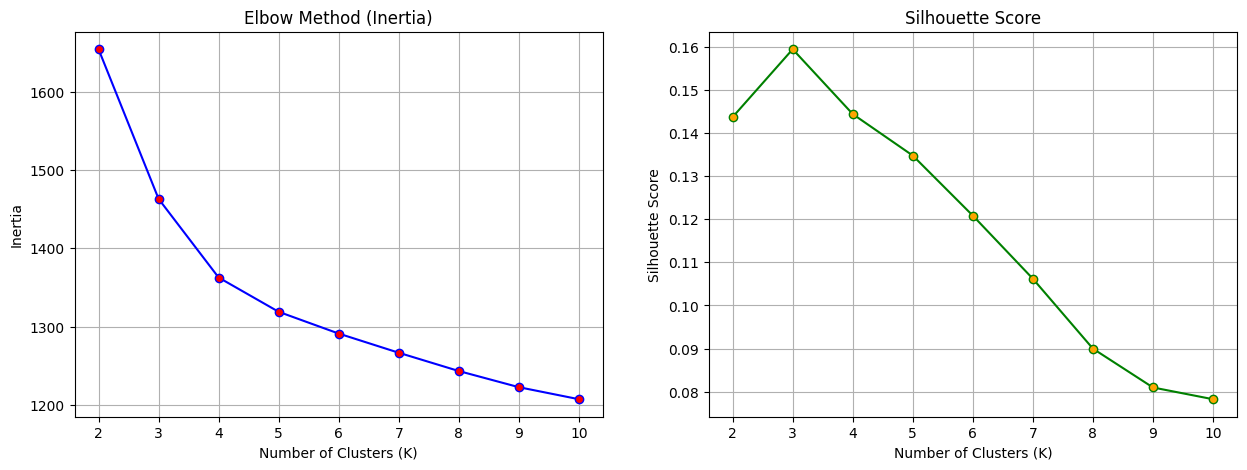

In [19]:
kmeans = KMeansClustering(X)
kmeans.evaluate_k()
kmeans.plot_results()

In [20]:
K_SIZE = 3

df = pd.read_csv("./clustered_SentenceTransformer.csv")
kmeans = kmeans.model(K_SIZE , init_method = "k-means++")
labels = kmeans.labels_
df["KMeans_Cluster"] = labels
df.to_csv("./clustered_SentenceTransformer.csv" , index=False)

# DBSCAN Clustering

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

class DBSCANClustering:
    def __init__(self, X, eps=0.5, min_samples=5):
        self.X = X
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    def evaluate_params(self , eps_range , min_samples_range):
        best_silhouette = -1
        best_params = None
        
        print(f"{'Eps':<6} | {'Min_S':<6} | {'Clusters':<9} | {'Noise(%)':<9} | {'Silhouette':<10}")
        for eps in eps_range:
            for min_samples in min_samples_range:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(self.X)

                clusters_num = len(set(labels)) - (1 if -1 in labels else 0)
                noise_num = list(labels).count(-1)
                noise_rate = (noise_num / len(labels))*100

                if(clusters_num > 1):
                    silhouette = silhouette_score(self.X, labels)
                else: 
                    silhouette = -1
                
                print(f"{eps:<6.2f} | {min_samples:<6} | {clusters_num:<9} | {noise_rate:<8.1f}% | {silhouette:<10.4f}")

                if silhouette > best_silhouette:
                    best_silhouette = silhouette
                    best_params = (eps, min_samples)
                    
        return best_params

    def model(self , eps , min_samples):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        self.labels = dbscan.fit_predict(self.X)
        return self.labels

In [22]:
eps_values = [0.1 , 0.2 ,0.3, 0.4, 0.5, 0.6, 0.7 , 0.8 , 0.9]
min_samples_values = [3, 4, 5, 6 ,7, 8, 9, 10]

dbscan = DBSCANClustering(X)
dbscan.evaluate_params(eps_values , min_samples_values)

Eps    | Min_S  | Clusters  | Noise(%)  | Silhouette
0.10   | 3      | 0         | 100.0   % | -1.0000   
0.10   | 4      | 0         | 100.0   % | -1.0000   
0.10   | 5      | 0         | 100.0   % | -1.0000   
0.10   | 6      | 0         | 100.0   % | -1.0000   
0.10   | 7      | 0         | 100.0   % | -1.0000   
0.10   | 8      | 0         | 100.0   % | -1.0000   
0.10   | 9      | 0         | 100.0   % | -1.0000   
0.10   | 10     | 0         | 100.0   % | -1.0000   
0.20   | 3      | 1         | 99.9    % | -1.0000   
0.20   | 4      | 0         | 100.0   % | -1.0000   
0.20   | 5      | 0         | 100.0   % | -1.0000   
0.20   | 6      | 0         | 100.0   % | -1.0000   
0.20   | 7      | 0         | 100.0   % | -1.0000   
0.20   | 8      | 0         | 100.0   % | -1.0000   
0.20   | 9      | 0         | 100.0   % | -1.0000   
0.20   | 10     | 0         | 100.0   % | -1.0000   
0.30   | 3      | 1         | 99.9    % | -1.0000   
0.30   | 4      | 0         | 100.0   % | -1.0

(0.7, 6)

In [23]:
EPS = 0.7
MIN_POINTS = 6

labels = dbscan.model(EPS , MIN_POINTS)
df = pd.read_csv("./clustered_SentenceTransformer.csv")
df["DBSCAN_Cluster"] = labels
df.to_csv("./clustered_SentenceTransformer.csv" , index=False)

# Hierarchical Clustering

In [24]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
class HierarchicalClustering:
    def __init__(self, X):
        self.X = X
        self.labels = None

    def plot_dendrogram(self, method='ward'):
        plt.figure(figsize=(10, 7))
        plt.title("Dendrogram")
        dendrogram = sch.dendrogram(sch.linkage(self.X, method=method))
        plt.xlabel("Samples")
        plt.ylabel("Distance")
        plt.show()

    def evaluate_methods(self , n_clusters):
        linkages = ['ward', 'complete', 'average', 'single']
        metrics = ['euclidean', 'cosine', 'manhattan']

        for method in linkages:
            for metric in metrics:
                try:
                    clustering = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=method)
                    labels = clustering.fit_predict(self.X)
                    silhouette = silhouette_score(self.X, labels)
                    print(f"Method: {method}, Metric: {metric}, Silhouette Score: {silhouette:.4f}")
                except Exception as e:
                    pass

    def model(self, n_clusters, linkage='ward', metric='euclidean'):
        clustering = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage)
        self.labels = clustering.fit_predict(self.X)
        return self.labels

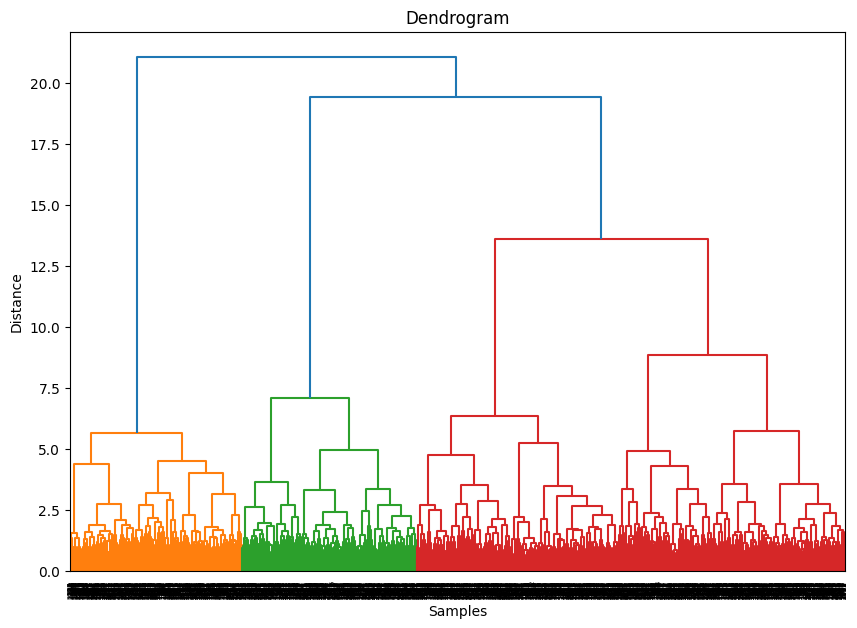

In [25]:
hierarchical = HierarchicalClustering(X)
hierarchical.plot_dendrogram(method='ward')

In [12]:
N_CLUSTERS = 3
hierarchical.evaluate_methods(n_clusters=N_CLUSTERS)

Method: ward, Metric: euclidean, Silhouette Score: 0.1572
Method: complete, Metric: euclidean, Silhouette Score: 0.1003
Method: complete, Metric: cosine, Silhouette Score: 0.1003
Method: complete, Metric: manhattan, Silhouette Score: 0.0796
Method: average, Metric: euclidean, Silhouette Score: 0.1308
Method: average, Metric: cosine, Silhouette Score: 0.0816
Method: average, Metric: manhattan, Silhouette Score: 0.1410
Method: single, Metric: euclidean, Silhouette Score: 0.0975
Method: single, Metric: cosine, Silhouette Score: 0.0975
Method: single, Metric: manhattan, Silhouette Score: 0.0975


In [26]:
METHOD = 'ward'
METRIC = 'euclidean'

labels = hierarchical.model(n_clusters=N_CLUSTERS, linkage=METHOD, metric=METRIC)
df = pd.read_csv("./clustered_SentenceTransformer.csv")
df["Hierarchical_Cluster"] = labels
df.to_csv("./clustered_SentenceTransformer.csv" , index=False)

# Reduction Dimensionality

## View clustering results with the SentenceTransformer model

/home/sadra/.local/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


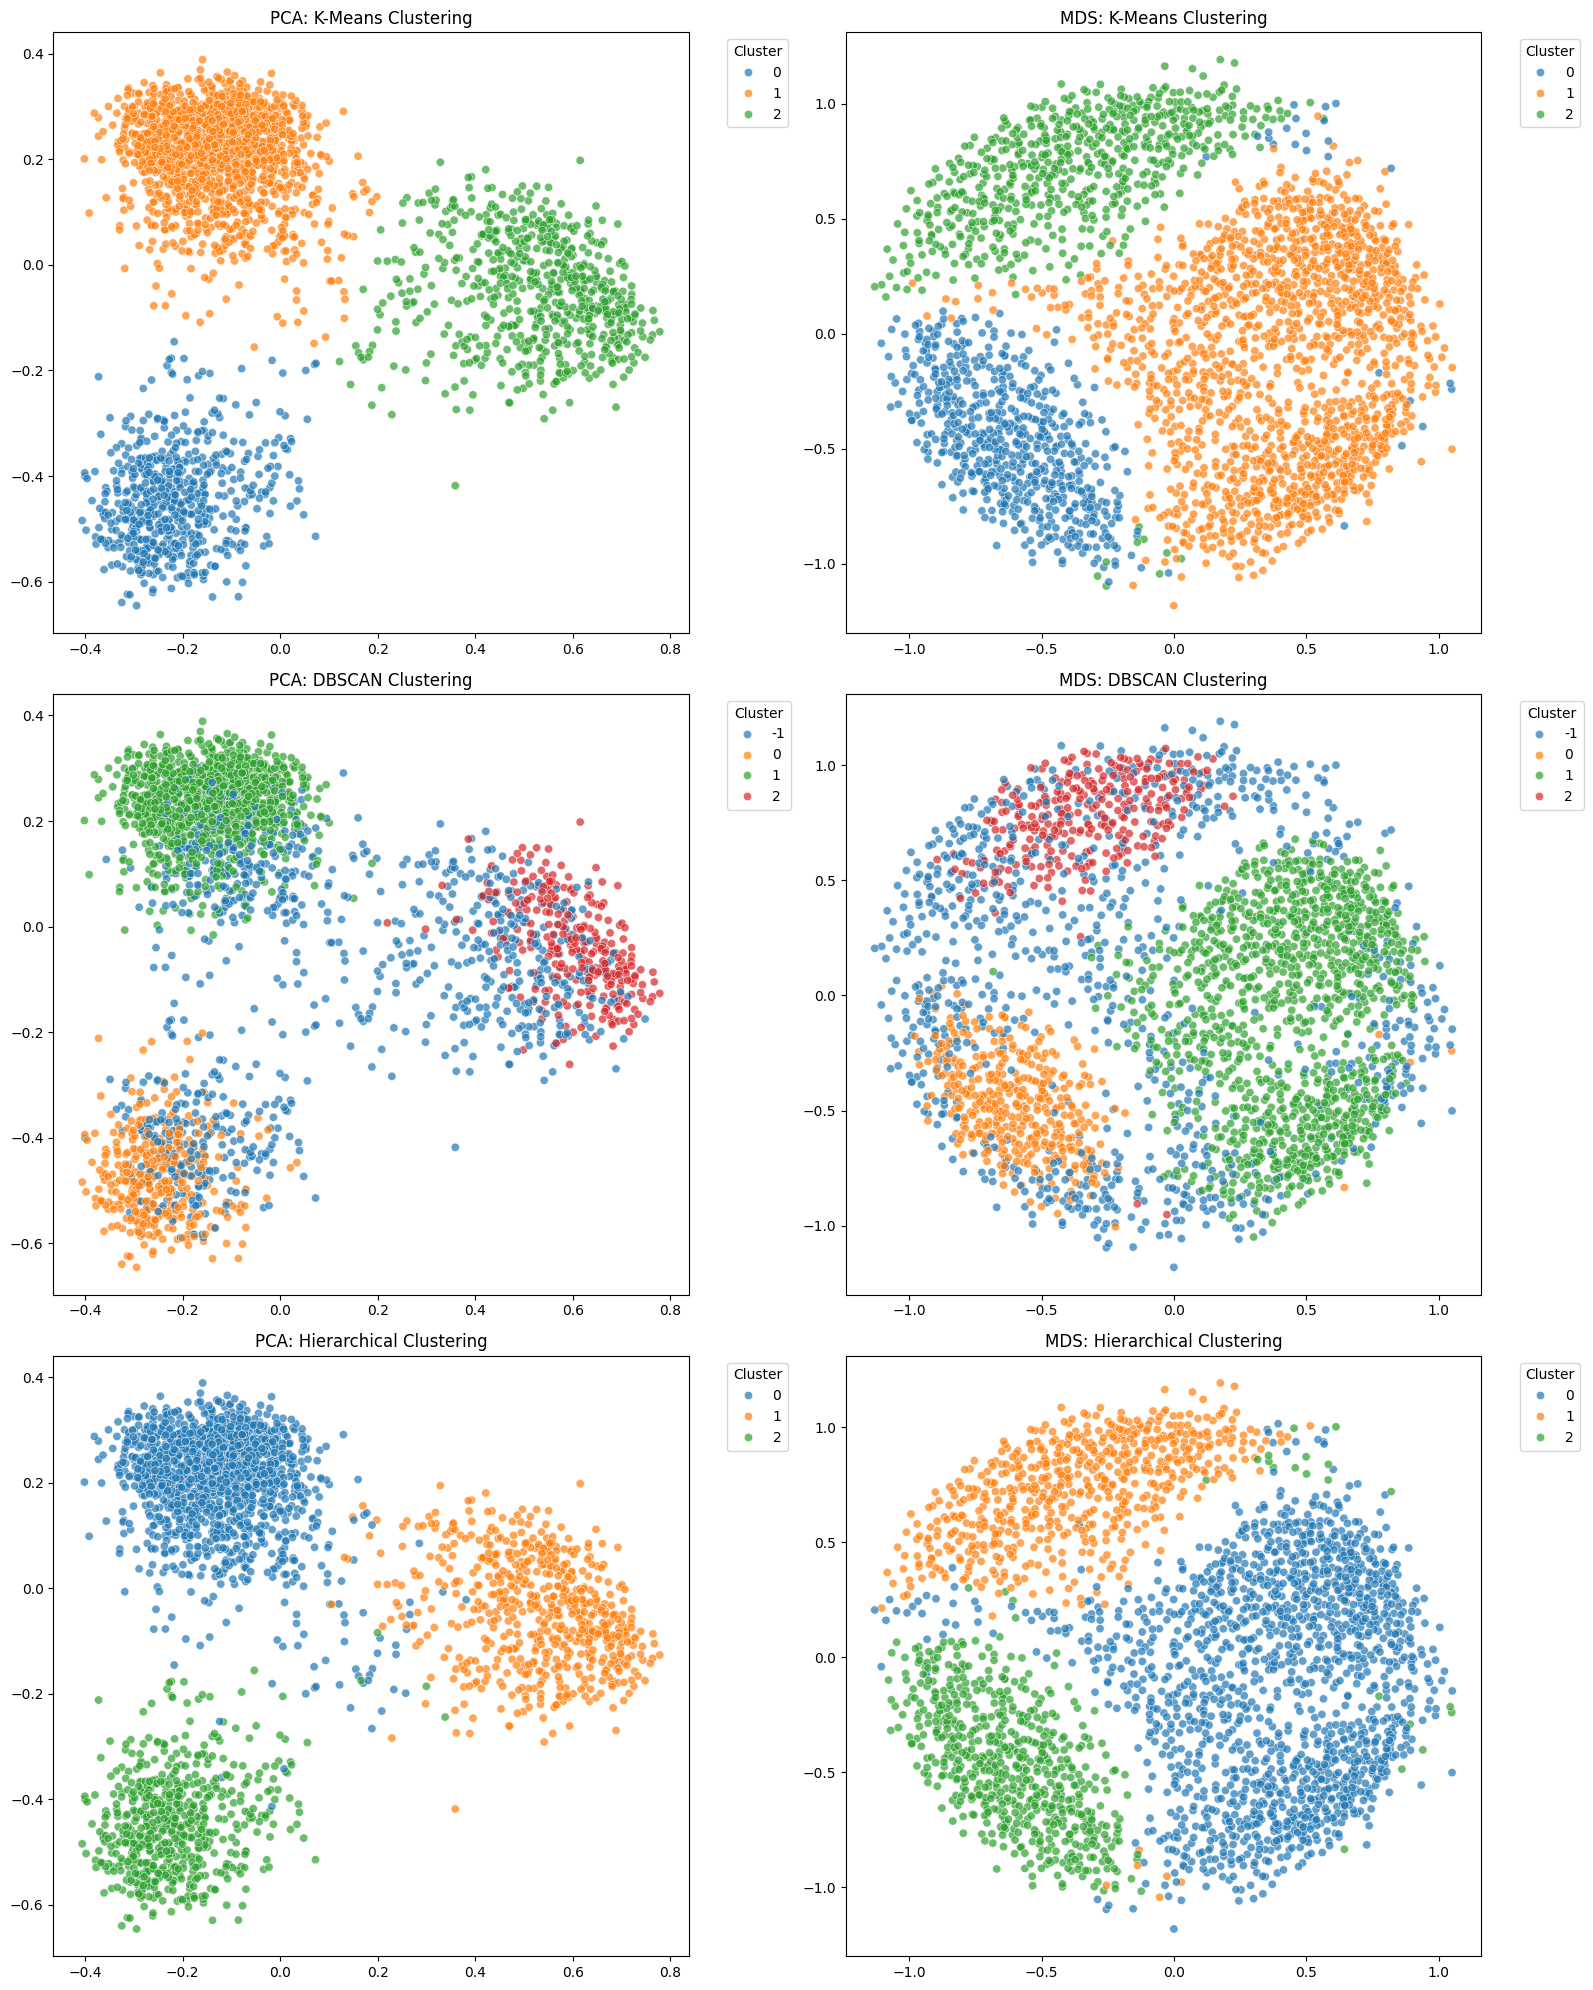

In [30]:
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2 , random_state=42)
X_pca = pca.fit_transform(X)

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X)

fig, axes = plt.subplots(3, 2, figsize=(16, 20))

clustering_columns = ['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']
titles = ['K-Means Clustering', 'DBSCAN Clustering', 'Hierarchical Clustering']

for i, (cluster_col, title) in enumerate(zip(clustering_columns, titles)):
    
    sns.scatterplot(
        x=X_pca[:, 0],        
        y=X_pca[:, 1],        
        hue=df[cluster_col], 
        palette='tab10',      
        ax=axes[i, 0],
        alpha=0.7             
    )
    axes[i, 0].set_title(f'PCA: {title}')
    axes[i, 0].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

    sns.scatterplot(
        x=X_mds[:, 0],       
        y=X_mds[:, 1],       
        hue=df[cluster_col], 
        palette='tab10', 
        ax=axes[i, 1],
        alpha=0.7
    )
    axes[i, 1].set_title(f'MDS: {title}')
    axes[i, 1].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Implementing clustering algorithms on reduced dimensional data

In [ ]:
df_pca = df.copy()
# df_mds = df.copy()

columns_to_drop = ['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']
df_pca = df_pca.drop(columns=columns_to_drop, errors='ignore')
# df_mds = df_mds.drop(columns=columns_to_drop, errors='ignore')

### PCA

#### K_means

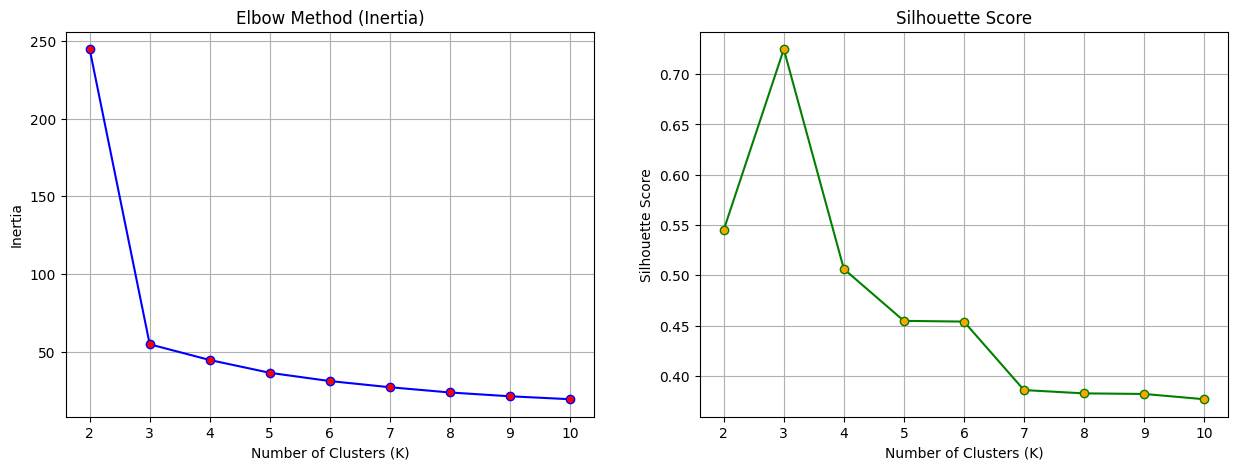

In [33]:
kmeans_pca = KMeansClustering(X_pca)
kmeans_pca.evaluate_k()
kmeans_pca.plot_results()

In [35]:
K_SIZE_PCA = 3
kmeans_pca = kmeans_pca.model(K_SIZE_PCA , init_method = "k-means++")
labels_pca = kmeans_pca.labels_
df_pca["KMeans_Cluster"] = labels_pca

#### DBScan

In [37]:
eps_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.1]
min_samples_values = [3, 4, 5, 6, 7]

dbscan_pca = DBSCANClustering(X_pca)
dbscan_pca.evaluate_params(eps_values , min_samples_values)

Eps    | Min_S  | Clusters  | Noise(%)  | Silhouette
0.01   | 3      | 162       | 29.0    % | -0.2693   
0.01   | 4      | 95        | 40.4    % | -0.3755   
0.01   | 5      | 62        | 50.1    % | -0.4425   
0.01   | 6      | 50        | 57.2    % | -0.4768   
0.01   | 7      | 32        | 64.6    % | -0.5191   
0.02   | 3      | 43        | 7.0     % | -0.0801   
0.02   | 4      | 27        | 11.1    % | -0.0596   
0.02   | 5      | 25        | 14.2    % | -0.0915   
0.02   | 6      | 22        | 17.4    % | -0.1006   
0.02   | 7      | 18        | 19.9    % | 0.0036    
0.03   | 3      | 22        | 2.5     % | 0.2074    
0.03   | 4      | 14        | 4.1     % | 0.2623    
0.03   | 5      | 7         | 5.7     % | 0.3817    
0.03   | 6      | 8         | 6.2     % | 0.2010    
0.03   | 7      | 8         | 7.5     % | 0.4018    
0.04   | 3      | 8         | 1.0     % | 0.3722    
0.04   | 4      | 7         | 1.6     % | 0.4195    
0.04   | 5      | 6         | 2.3     % | 0.41

(0.05, 7)

In [40]:
EPS_PCA = 0.05
MIN_POINTS_PCA = 7

labels = dbscan_pca.model(EPS_PCA , MIN_POINTS_PCA)
df_pca["DBSCAN_Cluster"] = labels

#### Hierarchical

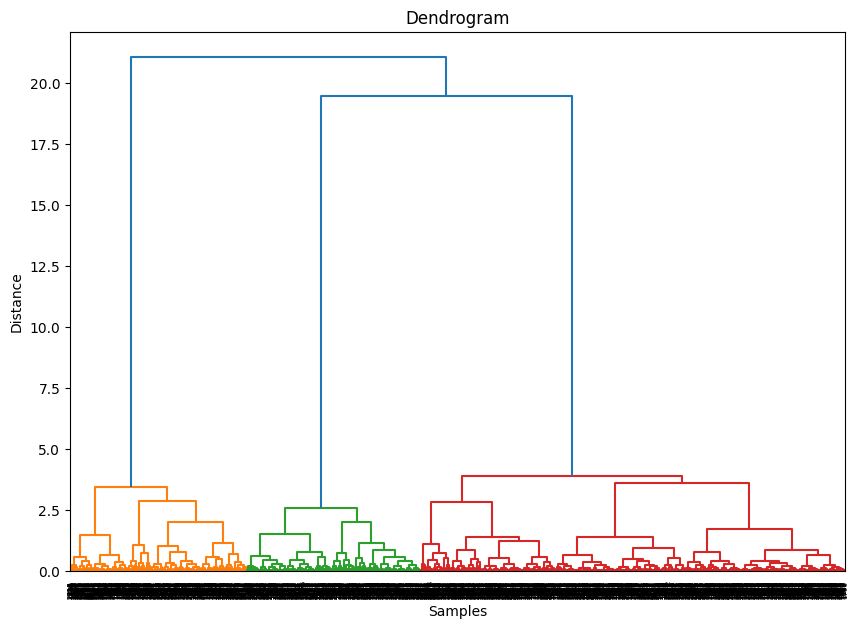

In [39]:
hierarchical_pca = HierarchicalClustering(X_pca)
hierarchical_pca.plot_dendrogram(method='ward')

In [41]:
N_CLUSTERS_PCA = 3
hierarchical_pca.evaluate_methods(n_clusters=N_CLUSTERS_PCA)

Method: ward, Metric: euclidean, Silhouette Score: 0.7237
Method: complete, Metric: euclidean, Silhouette Score: 0.7243
Method: complete, Metric: cosine, Silhouette Score: 0.7162
Method: complete, Metric: manhattan, Silhouette Score: 0.7204
Method: average, Metric: euclidean, Silhouette Score: 0.7148
Method: average, Metric: cosine, Silhouette Score: 0.7025
Method: average, Metric: manhattan, Silhouette Score: 0.7156
Method: single, Metric: euclidean, Silhouette Score: 0.1052
Method: single, Metric: cosine, Silhouette Score: 0.2343
Method: single, Metric: manhattan, Silhouette Score: 0.1052


In [42]:
METHOD_PCA = 'complete'
METRIC_PCA = 'euclidean'

labels = hierarchical_pca.model(n_clusters=N_CLUSTERS_PCA, linkage=METHOD_PCA, metric=METRIC_PCA)
df_pca["Hierarchical_Cluster"] = labels

In [43]:
df_pca.to_csv("./clustered_SentenceTransformer_PCA.csv" , index=False)

#### Show result

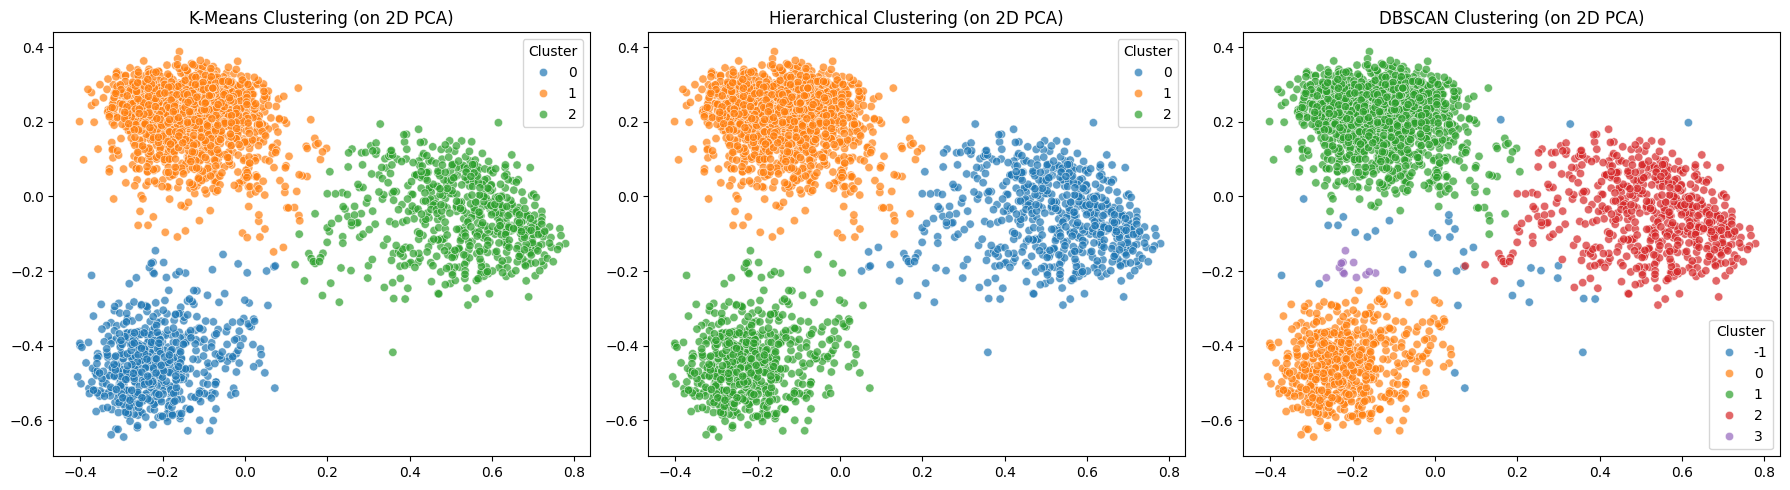

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df_pca['KMeans_Cluster'], 
    palette='tab10', ax=axes[0], alpha=0.7
)
axes[0].set_title('K-Means Clustering (on 2D PCA)')
axes[0].legend(title='Cluster', loc='best')

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df_pca['Hierarchical_Cluster'], 
    palette='tab10', ax=axes[1], alpha=0.7
)
axes[1].set_title('Hierarchical Clustering (on 2D PCA)')
axes[1].legend(title='Cluster', loc='best')

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df_pca['DBSCAN_Cluster'], 
    palette='tab10', ax=axes[2], alpha=0.7
)
axes[2].set_title('DBSCAN Clustering (on 2D PCA)')
axes[2].legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

# Evaluation

In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score


df_384 = pd.read_csv("clustered_SentenceTransformer.csv")
df_2d = pd.read_csv("clustered_SentenceTransformer_PCA.csv")

def calculate_silhouette(data_matrix, labels):
    if len(set(labels)) > 1:
        mask = labels != -1 
        if len(set(labels[mask])) > 1:
            score = silhouette_score(data_matrix[mask], labels[mask])
            return round(score, 4)
        else:
            score = silhouette_score(data_matrix, labels)
            return round(score, 4)
    else:
        return "N/A"

scores_data = {
    "Algorithms": ["K-Means", "Hierarchical", "DBSCAN"],
    
    "Silhouette Score (384d)": [
        calculate_silhouette(X, df_384['KMeans_Cluster']),
        calculate_silhouette(X, df_384['Hierarchical_Cluster']),
        calculate_silhouette(X, df_384['DBSCAN_Cluster'])
    ],
    
    "Silhouette Score (2d)": [
        calculate_silhouette(X_pca, df_2d['KMeans_Cluster']),
        calculate_silhouette(X_pca, df_2d['Hierarchical_Cluster']),
        calculate_silhouette(X_pca, df_2d['DBSCAN_Cluster'])
    ]
}

results_df = pd.DataFrame(scores_data)


print(results_df.to_markdown(index=False))

| Algorithms   |   Silhouette Score (384d) |   Silhouette Score (2d) |
|:-------------|--------------------------:|------------------------:|
| K-Means      |                    0.1594 |                  0.7249 |
| Hierarchical |                    0.1572 |                  0.7243 |
| DBSCAN       |                    0.1993 |                  0.579  |


# Report

<!DOCTYPE html>
<html lang="fa" dir="rtl">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1"/>
  <title>گزارش تمرین کامپیوتری شماره پنج - هوش مصنوعی</title>

  <style>
    /* ===== Minimal, clean RTL styling (no backgrounds) ===== */
    body{
      margin: 24px;
      font-family: Tahoma, "Vazirmatn", "IRANSans", Arial, sans-serif;
      font-size: 16px;
      line-height: 1.9;
      color: #111;
      direction: rtl;
      text-align: right;
      unicode-bidi: plaintext;
    }

    h1{ font-size: 22px; margin: 0 0 10px; }
    h2{ font-size: 18px; margin: 26px 0 10px; }
    h3{ font-size: 16px; margin: 16px 0 8px; }

    .meta{ margin: 6px 0 0; font-size: 14px; color:#333; }

    hr{ border: none; border-top: 1px solid #999; margin: 18px 0; }

    /* Simple boxed blocks (no background) */
    .box{
      border: 1px solid #999;
      padding: 12px 12px;
      margin: 12px 0;
    }

    /* Tables */
    table{
      width: 100%;
      border-collapse: collapse;
      margin: 10px 0 14px;
      font-size: 15px;
    }
    th, td{
      border: 1px solid #999;
      padding: 8px;
      vertical-align: top;
    }
    th{ font-weight: 700; }

    /* Lists */
    ul, ol{ margin: 6px 0 10px; padding-right: 22px; }
    li{ margin: 4px 0; }

    /* Code-like blocks (keep LTR) */
    pre, .code{
      border: 1px solid #999;
      padding: 10px 12px;
      margin: 10px 0 12px;
      white-space: pre-wrap;
      word-break: break-word;
      direction: ltr;
      text-align: left;
      unicode-bidi: isolate;
      font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, "Liberation Mono","Courier New", monospace;
      font-size: 14px;
      line-height: 1.7;
    }

    /* Figures / images placeholders */
    figure{
      margin: 12px 0 16px;
      border: 1px solid #999;
      padding: 10px;
    }
    figure img{
      display: block;
      width: 100%;
      height: auto;
      max-height: 700px;     /* you can change */
      object-fit: contain;   /* prevents cropping */
    }
    figcaption{
      margin-top: 10px;
      font-size: 14px;
      color: #333;
    }

    .center{ text-align: center; }
    .small{ font-size: 14px; color:#333; }
  
  /* RTL enforcement (strong) */
  html, body, .box, p, div, h1, h2, h3, ul, ol, li, table, th, td, figcaption{
    direction: rtl !important;
    text-align: right !important;
  }

  /* Better bidi handling for mixed Persian/English */
  body{
    unicode-bidi: plaintext;
  }

  /* Keep code blocks LTR */
  pre, .code{
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: isolate;
  }

  /* Fix list indentation in RTL */
  ul, ol{
    padding-right: 28px !important;
    padding-left: 0 !important;
    margin-right: 0 !important;
  }

  </style>
</head>

<body>

  <!-- پیش پردازش -->
  <h2>پیش پردازش</h2>

  <h3>کلاس TextPreProc:</h3>
  <p>
    به طور کلی این کلاس ترکیبی از چند عملیات پیش پردازش را روی یک متن ورودی انجام می دهد که شامل:
    حذف لینک ها و منشن ها - حذف کاراکتر های نویزی مانند ساختار های html و حروف غیر الفبایی -
    حذف stopword های انگلیسی - ریشه یابی کلمات استفاده شده بر اساس متدی که مشخص شده که
    می تواند lemmatization یا stemming باشد
  </p>

  <h3>سوالات:</h3>

  <div class="box">
    <div style="font-weight:700;">● دلیل انجام پیش پردازش روی داده های متنی</div>
    <p>
      داده های اولیه متنی معمولا شامل کاراکتر های نویزی است که کمکی به خوشه بندی محتوایی نمی کنند
      و هم در مدل خطا ایجاد می کنند.<br/>
      از آنجایی هر کلمه یکتا در داده متنی به عنوان یک بعد یا ویژگی در نظر گرفته می شود, وجود stopword ها
      ابعاد این ماتریس را زیاد می کند و باعث پردازش اضافی و بی فایده می شود.<br/>
      کلماتی که ریشه و مفهوم یکسانی دارند ممکن است به دلیل ساختار جمله یا شکل نوشتاری متفاوت به شکل های
      متفاوتی در متن وجود داشته باشند در این صورت مدل نباید به اشتباه آنها را به عنوان کلمات متفاوت در نظر بگیرد.
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">● تفاوت stemming و lemmatization به همراه مزایا و معایب هر کدام</div>

  <table>
      <thead>
        <tr>
          <th>روش</th>
          <th>stemming</th>
          <th>lemmatization</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <th>کارکرد</th>
          <td>برای ایجاد ریشه, انتهای کلمات را حذف می کند مثل حذف ing</td>
          <td>برای پیدا کردن ریشه, کلمات را در دیکشنری جستجو می کند</td>
        </tr>
        <tr>
          <th>مزایا</th>
          <td>سادگی و سرعت بیشتر</td>
          <td>ایجاد کلمات معنا دار و هوشمندی بیشتر</td>
        </tr>
        <tr>
          <th>معایب</th>
          <td>
            بی دقت تر است چون ممکن است یک کلمه بی معنا تولید کند مثال:
            Happily -> happi
          </td>
          <td>
            کند تر است چون نیازی به جستجو در دیکشنری دارد و همچنین نیازی به دیتا بیس
          </td>
        </tr>
      </tbody>
    </table>
  </div>

  <div class="box">
    <div style="font-weight:700;">● چرا استخراج ویژگی ضروری است و نمیتوان مستقیماً از متن خام برای خوشهبندی استفاده کرد؟</div>
    <p>
      الگوریتم های خوشه بندی بر اساس فاصله هندسی کار می کنند بنابراین نمی توان از داده های متنی در این
      الگوریتم های استفاده کرد و باید آنها را به عدد تبدیل کرد
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">● کدام روش یا ترکیب روشهای پیشپردازش عملکرد بهتری داشته است؟</div>
    <p>
      برای بررسی عملکرد هر روش, ماکزیمم امتیاز Silhouette Score مدل K-means را برای هر کدام حساب کرده و
      مقایسه می کنیم:
    </p>
    <p><strong>Preprocess + Lemmatization:</strong></p>
    <figure>
      <img src="assets/k-means_plot_lemm.png" alt="Preprocess + Lemmatization" />
      <figcaption>
      </figcaption>
  </figure>
    <p><strong>Preprocess + Stemming:</strong></p>
    <figure>
      <img src="assets/k-means_plot_stemm.png" alt="Preprocess + Stemming" />
      <figcaption>
      </figcaption>
  </figure>
    <p>
      با مقایسه ماکزیمم امتیاز ها که برای روش اول 0.16 و برای روش دوم 0.14 است نتیجه می گیریم روش اول
      عملکرد بهتری دارد
    </p>
  
  </div>

  <!-- فرایند حل مسئله -->
  <h2>فرایند حل مسئله</h2>

  <h3>کلاس Vectorization:</h3>
  <p>
    وظیفه اصلی این کلاس تبدیل داده های متنی به داده های عددی است که در الگوریتم ها استفاده می شوند.
    ابتدا fields_extract فراخوانی می شود با استفاده از expression regular متن اصلی و خلاصه متن
    (که با text و summary در داده های خام وجود دارند) را استخراج می کند و در یک ستون مجزا در دیتا فریم قرار می دهد.
    سپس روی این دو ستون جدید از متد text_process (از کلاس TextPreProc) استفاده می شود تا پیش پردازش روی این
    دو ستون انجام شود و این داده های پیش پردازش شده دوباره در ستون های جدیدی از دیتا فریم قرار می گیرند.
    چیزی که به عنوان داده نهایی برای ورودی دادن به مدل all-MiniLM-L6-v2 در نظر گرفته می شود, ترکیبی از خلاصه
    و متن پیش پردازش شده برای هر سطر است که به این شکل ترکیب می شوند: text . summary و در ستون جدیدی قرار می گیرند.
    مدل متن های این ستون را encode کرده یک بردار متراکم با ابعاد ۳۸۴ تولید می کند.<br/>
    خروجی های کلاس: دیتا فریم ساخته شده در پایپ لاین + ماتریس ویژگی ها به ابعاد 384*N
  </p>

  <!-- K-means -->
  <h2>K-means Clustering</h2>

  <h3>کلاس KMeansClustering:</h3>
  <p>
    به طور کلی هدف این کلاس اجرای الگوریتم K-means است که این پیاده سازی توسط کلاس KMeans در کتابخانه scikit-learn انجام شده
    و به هنگام instance گرفتن از آن باید چند پارامتر مهم را تعیین کنیم:
  </p>

  <ul>
    <li><strong>clusters_n</strong>: برای تعداد خوشه هاست</li>
    <li><strong>init</strong>: روش مقدار دهی اولیه را مشخص می کند اگر 'random' باشد نقاط تصادفی را به عنوان مرکز خوشه ها انتخاب می کند
      و اگر 'k-means++' باشد مراکز اولیه را به صورت با فاصله زیاد از هم انتخاب می کند که باعث تسریع فرایند همگرایی الگوریتم می شود</li>
    <li><strong>init_n</strong>: تعیین می کند که الگوریتم چند بار با seed های مختلف اجرا شود (در نهایت مدلی که کمترین میزان خطا SSE را داشته بر می گرداند)</li>
    <li><strong>iter_max</strong>: حداکثر تکرار الگوریتم در صورت عدم همگرایی را تعیین می کند</li>
  </ul>

  <p>این کلاس شامل اجزای اصلی زیر است:</p>
  <ul>
    <li><strong>متد k_evaluate</strong>: الگوریتم K-means را برای یک رنج مشخص از k اجرا می کند و در هر تکرار دو معیار SSE و Silhouette Score را محاسبه می کند</li>
    <li><strong>متد result_plot</strong>: نتایج عددی حاصل از متد قبلی را plot می کند تا برای تصمیم گیری درباره مقدار هایپرپارامترها از آن استفاده کنیم</li>
    <li><strong>متد model</strong>: این متد مدل K-means را روی داده ها و با استفاده از k ای که ورودی گرفته آموزش می دهد و label های نهایی را برای هر داده بر می گرداند</li>
  </ul>

  <h3>پارامترها:</h3>
  <p><strong>K</strong>: تعداد خوشه ها یا مراکز</p>

  <h3>معیار انتخاب مقدار پارامترها:</h3>
  <p>
    برای پیدا کردن k مناسب از معیار SSE استفاده شده که مجموع مربع خطاها را محاسبه می کند, منظور از خطا, فاصله هر داده از مرکز خوشه خود است.
    مراحل ارزیابی به این شکل است که برای یک رنج از مقادیر k الگوریتم را اجرا می کنیم و میزان SSE را ذخیره می کنیم در ادامه با plot کردن این مقادیر
    و با استفاده از روش elbow, مقدار بهینه برای k را تخمین می زنیم.
  </p>

  <p><strong>نمودار SSE/k:</strong></p>

  <figure>
    <img src="assets/k-means_plot_lemm.png" alt="KMeans Elbow and Silhouette" />
    <figcaption>شکل 2 — نمودار Elbow (SSE) و Silhouette برای K-means.</figcaption>
  </figure>

  <p>
    با توجه به plot خروجی مقدار ۳ برای k همان نقطه شکستگی است که طبق method elbow می تواند انتخاب مناسبی برای k باشد
    البته ۴ هم به نوعی می تواند elbow باشد برای قضاوت نهایی بین انتخاب ۳ یا ۴ از معیار Silhouette استفاده کردیم
    که برای 3 = k مقدار بیشتری دارد
  </p>

  <!-- DBSCAN -->
  <h2>DBSCAN Clustering</h2>

  <h3>کلاس DBSCANClustering:</h3>
  <p>
    این کلاس الگوریتم DBSCAN را با استفاده از کتابخانه scikit-learn اجرا می کند و برای اجرای آن باید ابتدا دو پارامتر را مشخص کرد:
    eps یا همان شعاع همسایگی نقاط و همچنین samples_min یعنی حداقل نقاطی که باید در همسایگی یک نقطه وجود داشته باشند
    تا آن نقطه تبدیل به یک point core یا خوشه شود
  </p>

  <p>این کلاس شامل اجزای اصلی زیر است:</p>
  <ul>
    <li><strong>متد params_evaluate</strong>: یک گرید سرچ روی تمام ترکیبات اعضای دامنه eps و samples_min انجام می دهد و در هر step مقدار امتیاز Silhouette و همچنین نرخ داده های نویز و تعداد خوشه ها را محاسبه می کند. از این متد برای پیدا کردن مقدار مناسب برای پارامتر های مدل استفاده می کنیم</li>
    <li><strong>متد model</strong>: این متد مدل DBSCAN را روی داده ها و با استفاده از eps و samples_min ای که ورودی گرفته آموزش می دهد و label های نهایی را برای هر داده بر می گرداند</li>
  </ul>

  <h3>پارامترها:</h3>
  <ul>
    <li><strong>Eps</strong>: شعاع همسایگی نقاط</li>
    <li><strong>samples_Min</strong>: حداقل نقاطی که باید در همسایگی وجود داشته باشند تا آن نقطه تشکیل یک خوشه دهد. اگر این تعداد را کم درنظر بگیریم تعداد زیادی خوشه کوچک خواهیم داشت و اگر بزرگ درنظر بگیریم خوشه های کم و نویز های زیاد خواهیم داشت بنابراین هدف برقراری تعادل بین داده های نویز و تعداد و جمعیت خوشه هاست</li>
  </ul>

  <h3>معیار انتخاب مقدار پارامترها:</h3>
  <p>
    در واقع برای پیدا کردن مقادیر بهینه باید تعدادی معیار را به صورت همزمان مورد ارزیابی قرار دهیم.
    برای این کار از یک گرید سرچ برای تست کردن حالت های مختلف استفاده شده و هدف این است که مقادیری را پیدا کنیم که به ازای آنها
    داده های نویز نرخ کمی داشته باشند در حالی که امتیاز Silhouette نسبتا بالا باشد؛ در واقع باید به یک تعادل مناسب بین این دو معیار برسیم.
    از طرفی تعداد خوشه ها باید معقول باشد نه آنقدر زیاد که خوشه بندی بی معنا شود و تحلیل روی آنها دشوار باشد و نه آنقدر کم که خوشه بندی
    خاصی وجود نداشته باشد.
  </p>

  <p><strong>نتیجه تست برای مقادیر دامنه:</strong></p>
  <div class="code">eps_values = [0.1 , 0.2 ,0.3, 0.4, 0.5, 0.6, 0.7 , 0.8 , 0.9]
min_samples_values = [3, 4, 5, 6 ,7, 8, 9, 10]</div>

  <p>
    با توجه به بررسی نتایج بدست آمده بهترین انتخاب 0.7 = eps و 6 = points_min است که به ازای آن خوشه بندی به صورت زیر خواهد بود:
  </p>

  <table>
    <thead>
      <tr>
        <th>Eps</th>
        <th>Min_S</th>
        <th>Clusters</th>
        <th>Noise(%)</th>
        <th>Silhouette</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td>0.70</td>
        <td>6</td>
        <td>3</td>
        <td>32.9 %</td>
        <td>0.0838</td>
      </tr>
    </tbody>
  </table>

  <!-- Hierarchical -->
  <h2>Hierarchical Clustering</h2>

  <h3>کلاس HierarchicalClustering:</h3>
  <p>
    این کلاس الگوریتم خوشه بندی سلسله مراتبی را با استفاده از کتابخانه scikit-learn پیاده سازی و ارزیابی می کند.
    رویکرد تجمعی یا Agglomerative برای اجرای الگوریتم پیاده سازی شده که در آن خوشه ها از پایین به بالا ادغام می شوند
  </p>

  <h3>اجزای اصلی کلاس:</h3>
  <ul>
    <li><strong>متد dendrogram_plot</strong>: این متد وظیفه رسم و نمایش نمودار دندروگرام را بر عهده دارد که با استفاده از آن نحوه ادغام خوشه ها و فواصل ادغام را مشاهده و ارزیابی می کنیم. محور عمودی نمودار فاصله ادغام و محور افقی سمپل های هر خوشه است</li>
    <li><strong>متد methods_evaluate</strong>: این متد ترکیب های مختلف از معیار های پیوند و توابع فاصله را ارزیابی می کند و برای هر ترکیب امتیاز Silhouette را محاسبه می کند تا به بهترین ترکیب برسیم</li>
    <li><strong>متد model</strong>: مدل نهایی را با پارامتر های بهینه آموزش می دهد و برچسب های خوشه بندی را برمی گرداند</li>
  </ul>

  <h3>پارامترها:</h3>
  <ul>
    <li><strong>clusters_N</strong>: تعداد خوشه هایی که نهایتا با ادغام های مرحله به مرحله باید بوجود بیایند</li>
    <li><strong>linkage</strong>: معیار ادغام خوشه ها را تعیین میکند (Average / Ward / Complete / Single)</li>
    <li><strong>Metric</strong>: نوع تابع فاصله را تعیین میکند (Euclidean / Cosine / Manhattan)</li>
  </ul>

  <h3>معیار انتخاب مقدار پارامترها:</h3>
  <p>
    برای یافتن مقدار مناسب clusters_n باید نمودار dendrogram را ارزیابی کنیم و طولانی ترین خط عمودی را
    (که ادغامی در طول آن صورت نگرفته) پیدا کنیم. سپس تعداد شاخه هایی که در تقاطع فرضی میانه این فاصله قرار دارند
    را به عنوان n انتخاب می کنیم, منطق انتخاب این است که فاصله خوشه ها در این حالت از هم زیاد بوده که در فاصله نسبتا طولانی ادغام صورت گرفته
    پس توقع داریم خوشه هایی نسبتا متراکم داشته باشیم که فاصله زیادی از هم دارند و این کاملا برای خوشه بندی مطلوب است.
  </p>

  <p><strong>نمودار dendrogram:</strong></p>
  <figure>
    <img src="assets/dendrogram_plot.png" alt="Dendrogram" />
    <figcaption>شکل 3 — نمودار دندروگرام برای انتخاب تعداد خوشه‌ها.</figcaption>
  </figure>

  <p>
    با توجه به این نمودار و منطق قبلی طولانی ترین خط عمودی بدون ادغام مربوط به بازه تقریبا ۶ تا تقریبا ۲۱ می شود
    که در این بازه، هر خط برش فرضی میتواند تعداد خوشههای متفاوتی (از ۲ تا ۷ خوشه) را پیشنهاد دهد.
    با این حال، مقدار 3=n انتخاب شد؛ زیرا در این سطح فاصله ادغام بعدی خوشه ها نسبتا بیشتر است تا مقادیر دیگر
    که نشان دهنده جدایی مطلوب تر است.
    برای پیدا کردن مقدار مناسب پارامتر های دیگر نیز, باید ترکیب های مختلف آنها را ارزیابی کرده و ترکیبی را انتخاب کنیم
    که به ازای آن بیشترین امتیاز Silhouette بدست آمده
  </p>

  <h3>نتیجه بررسی:</h3>
  <p>
    با توجه به مقادیر بدست آمده بهترین مقدار برای این هایپرپارامتر ها ترکیب زیر است:
  </p>

  <div class="code">Method: ward, Metric: euclidean, Silhouette Score: 0.1572</div>

  <figure>
    <img src="assets/hierarchical_evaluation.png" alt="Hierarchical methods evaluation table" />
    <figcaption>شکل 4 — نتایج ارزیابی ترکیب‌های linkage و metric در Hierarchical.</figcaption>
  </figure>

  <!-- سوالات -->
  <h2>سوالات</h2>

  <div class="box">
    <div style="font-weight:700;">● روش های supervised learning و unsupervised learning را توضیح دهید و با هم مقایسه کنید</div>
    <p>
      در یادگیری با نظارت, داده های ورودی برچسب خورده هستند و هدف اصلی مدل یادگیری روابط بین داده های ورودی و برچسب هاست
      اما در یادگیری بدون نظارت, داده های ورودی بدون برچسب هستند و هدف مدل کشف کردن الگو ها, ساختار ها و گروه بندی داده ها
      به صورت خودکار است
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">● دلیل استفاده از بردار های ویژگی چیست؟ ویژگی های این بردار ها چیست</div>
    <p>
      بردارسازی در واقع یک متن را به یک فضای برداری نگاشت می کند و علت اصلی آن این است که مدل بتواند شباهت های معنایی را
      از طریق محاسبه فواصل هندسی کشف کند و بدیهی است که محاسبات روی متن امکان پذیر نیست.
      ویژگی ها: طول بردارها ثابت است / کلماتی که از نظر معنایی نزدیک تر اند, در این فضای برداری نیز بهم نزدیک تر اند /
      مقادیر بردار ها به صورت پیوسته و فشرده است
    </p>
  </div>

  <div class="box">
  <div style="font-weight:700;">
    ● روش های برداری سازی متن را توضیح دهید و آنها را از نظر کیفیت معنایی مقایسه کنید
  </div>

  <p>
    <span class="ltr">Bag of Words</span>:
    متن را بر اساس تکرار کلمات بردار سازی می کند. از آنجایی که ترتیب کلمات را در نظر نمی گیرد کیفیت نسبتا پایین تری دارد.
    <br/>

  <span class="ltr">TF-IDF</span>:
    این روش هم مثل <span class="ltr">Bag of Words</span> عمل می کند یعنی ابتدا بررسی می کند که هر کلمه چندبار در متن تکرار شده اما در ادامه بررسی می کند
    یک کلمه در کل چقدر کمیاب است و بر اساس آن به کلمات وزن می دهد و با این کار ارزش کلماتی که زیاد در متن تکرار شده اند اما فاقد ارزش معنایی هستند
    را کم می کند. به نسبت <span class="ltr">Bag of Words</span> بهتر است اما همچنان به دلیل در نظر نگرفتن ترتیب کلمات کیفیت پایینی دارد.
    <br/>

  <span class="ltr">Word Embedding</span>:
    هر کلمه را به بردار متراکمی تبدیل می کند که معنای آن کلمه را درون خود دارد.
    در واقع می تواند به کلمات معنا دهد اما آن را در زمینه جمله نمی فهمد؛
    یعنی ممکن است کلمه در جمله معنای متفاوتی دهد اما این روش متوجه این تغییر نمی شود.
    کیفیت بهتری نسبت به دو روش قبل دارد و می توان گفت کیفیت آن متوسط است.
    <br/>

  <span class="ltr">Sentence Embedding</span>:
    هم ترتیب کلمات و هم زمینه جمله را برای برداری سازی در نظر می گیرد در نتیجه بالاترین کیفیت را دارد.
  </p>
</div>


  <div class="box">
    <div style="font-weight:700;">● درباره مدل های Transformer Sentence و all-MiniLM-L6-v2 توضیح دهید</div>
    <p>
      Transformer Sentence: این مدل بجای اینکه برای هر کلمه یک بردار مستقل بسازد, کل کلمات جمله را باهم ترکیب کرده و یک بردار واحد با طول ثابت تولید می کند
      که حاوی مفهوم کلی جمله است. برای اینکار از ساختاری بنام شبکه های دوقلو استفاده می کند که این شامل دو شبکه عصبی کاملا یکسان است و دو جمله ورودی را به موازات هم
      پردازش می کنند. اینکار برای محاسبه سریع میزان شباهت معنایی متون است.<br/><br/>
      all-MiniLM-L6-v2:<br/>
      All: این مدل رو مجموعه بسیار عظیمی از متون مختلف آموزش داده شده است.<br/>
      miniLm: این مدل بر اساس تکنیک «تقطیر دانش» (Knowledge Distillation) ساخته شده است. در این تکنیک، دانش و الگوهای یادگیرِی یک مدل بسیار بزرگ، پیچیده و کند
      (مدل استاد/Teacher)، فشرده‌سازی شده و به یک مدل کوچکتر (مدل شاگرد/Student) منتقل میشود. با این کار، مدل کوچکتر عملکردی نزدیک به مدل بزرگ (حفظ بیش از %۹۰ دقت)
      را با حجم و مصرف منابع بسیار کمتر ارائه میدهد.<br/>
      6L: این شبکه عصبی از ۶ لایه پردازشی تشکیل شده.<br/>
      خروجی مدل: با ورودی گرفتن متن (با هر طولی), آن را به یک فضای برداری با طول ثابت 384 نگاشت می کند که این بردار حاوی معنای دقیق آن جمله در فضای ریاضی است
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">● روش method elbow چیست و چگونه از آن برای انتخاب تعداد خوشه ها استفاده می شود</div>
    <p>
      در این روش, K-means برای بازه ای از مقادیر k اجرا می شود و در هر اجرا مجموع مربعات فاصله هر نقطه از مرکز خوشه آن محاسبه می شود که به آن SSE می گوییم.
      سپس با ساختن نمودار K_SSE که در واقع محور عمودی آن SSE و محور افقی آن K هست دنبال نقطه ای می گردیم که شیب تابع از حالت خیلی تند به حالت کند تغییر کند,
      این نقطه تعادل مناسبی بین مینیمم سازی خطا و پیچیدگی مدل برقرار می کند
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">● روش های خوشه بندی استفاده شده را توضیح دهید</div>
    <p>
      Means-K: الگوریتمی افرازی که داده ها را به K خوشه مجزا تقسیم می کند. نقاط را به نزدیکترین مرکز اختصاص داده و مراکز را به صورت تکرارشونده تا همگرایی کامل به‌روزرسانی می کند.
      به تعداد خوشه اولیه نیاز دارد، فرض می کند خوشه ها کروی هستند و به شدت تحت تأثیر داده های پرت قرار می گیرد.<br/>
      DBSCAN: الگوریتمی که نقاط متراکم را به هم متصل کرده و خوشه هایی با اشکال هندسی نامنظم می سازد. به جای دریافت تعداد خوشه، دو پارامتر eps (شعاع همسایگی) و samples_min
      (حداقل نقاط لازم برای تشکیل یک ناحیه متراکم) را دریافت میکند. بزرگترین مزیت آن شناسایی داده های دورافتاده (پراکنده) و حذف آنها به عنوان نویز (برچسب -1) است.<br/>
      Clustering Hierarchical: الگوریتمی که از پایین به بالا کار می کند. ابتدا هر نقطه یک خوشه مجزا فرض می شود. در هر مرحله، شبیه ترین خوشه ها بر اساس یک تابع فاصله و یک معیار پیوند با هم ادغام می شوند
      تا در نهایت یک ساختار درختی به نام دندروگرام ساخته شود.
    </p>
  </div>

  <!-- کاهش بعد -->
  <h2>کاهش بعد</h2>
  <p>
    در این بخش از دو روش PCA و MDS برای کاهش بعد داده ها استفاده شده. با این دو روش نتایج خوشه بندی الگوریتم های قبلی روی داده های ۳۸۴ بعدی به صورت زیر خواهد بود:
  </p>

  <figure>
    <img src="assets/visual_kmeans.png" alt="PCA and MDS plots for clustering results" />
    <img src="assets/visual_dbscan.png" alt="PCA and MDS plots for clustering results" />
    <img src="assets/visual_hierarchical.png" alt="PCA and MDS plots for clustering results" />
    <figcaption>شکل 5 — نمایش نتایج خوشه‌بندی در فضای 2D با PCA و MDS.</figcaption>
  </figure>

  <h3>مقایسه الگوریتم های خوشه بندی:</h3>
  <p>
    می توان مشاهده کرد که دو الگوریتم K-means و Hierarchical تا حد زیادی خوشه بندی مشابه انجام داده اند و به طور کلی داده ها را در ۳ خوشه مجزا تشخیص داده اند.
    همچنین بدلیل hard clustering بودن این الگوریتم ها, همه داده ها به یکی از ۳ خوشه map شده اند.
    از طرفی DBSCAN رفتار منحصر بفردی از خود نشان داده است, در نواحی ای که تراکم زیادی از داده ها وجود داشته, هر داده به یکی از ۳ خوشه اصلی تعلق یافته
    اما در نواحی اطراف آنها که تراکم کمتر بوده داده های زیادی را به عنوان نویز تشخیص داده است
  </p>

  <div class="box">
    <div style="font-weight:700;">● درباره PCA تحقیق کرده و نحوه عملکرد آن را توضیح دهید</div>
    <p>
      هدف اصلی این روش این است که ابعاد داده ها را طوری کاهش دهد که بیشترین اطلاعات و تفاوت های بین داده ها حفظ شود و اینکار را از طریق یک تبدیل خطی انجام می دهد:<br/>
      -۱ محاسبه میانگین همه داده ها و انتقال محور های مختصات به مرکز ثقل داده ها<br/>
      -۲ پیدا کردن محوری که وقتی داده ها روی آن تصویر می شوند بیشترین گستردگی را داشته باشند<br/>
      -۳ پیدا کردن محوری که دقیقا به محور اول عمود باشد و بیشترین پراکندگی باقی مانده را توضیح دهد<br/>
      -۴ برای هر داده تنها مختصات آن روی این دو مولفه ۲ و ۳ به عنوان ابعاد جدید نگه داشته می شود
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">● عملکرد دو روش کاهش بعد استفاده شده را مقایسه کنید</div>
    <p>
      روش PCA مبتنی بر واریانس است و برای پیدا کردن محور های اصلی, ساختار کلی داده ها را در نظر می گیرد در نتیجه محور هایی را می سازد که تفاوت های بزرگ داده ها روی آن محور ها برجسته تر باشد
      اما روش MDS بر اساس فواصل هندسی کار می کند و با محاسبه فاصله هندسی تک تک داده ها در فضای ۳۸۴ بعدی, نقاط را طوری در فضا توزیع می کند که فاصله آنها تا حد امکان حفظ شود و مانند فضای اصلی ۳۸۴ بعدی باقی بماند.<br/>
      در نتیجه منطق عملکرد این دو روش مشاهده می شود که PCA توانسته ۳ ناحیه کاملا مجزا و با فاصله زیاد از هم را نشان دهد اما روش MDS داده ها به شکل پیوسته تری در ۳ ناحیه اصلی توزیع شده اند
      و دلیل این موضوع پیوستگی معنایی ذاتی داده های متنی است و این روش سعی کرده تا حد امکان توزیع نزدیک به واقعیت را برای ما تصویر کند
    </p>
  </div>

  <!-- ارزیابی -->
  <h2>ارزیابی</h2>

  <h3>معیار های ارزیابی:</h3>

  <div class="box">
    <div style="font-weight:700;">Silhouette</div>
    <p>
      این معیار کیفیت خوشه بندی را بر اساس دو مفهوم زیر اندازه گیری می کند:<br/>
      انسجام: نزدیکی داده های داخل یک خوشه<br/>
      تفکیک: دوری داده های داخل خوشه های مجاور
    </p>

  <p>برای هر داده i این دو مقدار حساب می شود:</p>
    <ul>
      <li><strong>a(i)</strong>: میانگین فاصله i از همه نقاط دیگر در همان خوشه</li>
      <li><strong>b(i)</strong>: کمترین میانگین فاصله نقطه i از تمام نقاط موجود در نزدیکترین خوشه همسایه (خوشه ای که نقطه i به آن تعلق ندارد)</li>
    </ul>

  <div class="code">s(i) = [b(i) - a(i)] / max(a(i), b(i))</div>

  <p>
      امتیاز کل مدل برابر میانگین s(i) برای تمام نقاط است که مقدار آن بین 1- و 1 می تواند باشد. هرچه به یک نزدیکتر باشد یعنی خوشه بندی بهتر است
    </p>
  </div>

  <div class="box">
    <div style="font-weight:700;">همگنی (Homogeneity Score)</div>
    <p>
      معیار همگنی یک ارزیابی بیرونی است. یک خوشه بندی زمانی کاملا همگن است که هر خوشه فقط و فقط شامل داده هایی باشد که در واقعیت متعلق به یک کلاس واحد هستند.
    </p>

  <p><strong>فرمول محاسبه:</strong></p>
    <div class="code">h = 1 - [ H(C|K) / H(C) ]</div>

  <ul>
      <li><strong>H(C|K)</strong>: آنتروپی شرطی کلاس های واقعی به شرط خوشه های پیشبینی شده</li>
      <li><strong>H(C)</strong>: آنتروپی کلاس های واقعی</li>
    </ul>

  <p>
      می توان نتیجه گرفت که استفاده از این معیار به دلیل عدم دسترسی به برچسب های واقعی امکان پذیر نیست.
    </p>
  </div>

  <h3>مقایسه حالت خوشه بندی برای داده های d2 و d384:</h3>

  <figure>
    <img src="assets/silhouette_scores.png" alt="Silhouette comparison for 384d vs 2d" />
  </figure>
  <figure>
    <img src="assets/visual_2d.png" alt="Silhouette comparison for 384d vs 2d" />
  </figure>

  <p>
    با توجه به مقادیر جدول، اختلاف زیادی بین امتیازات دو فضا وجود دارد؛ اما این اختلاف لزوما به دلیل کیفیت خیلی بالاتر خوشه بندی یا درک عمیقتر مدل نیست.
    در فضای ۳۸۴ بعدی، مدل با داده هایی کار می کند که پیچیدگی بالایی دارند و مرزهای معنایی متن ها معمولا به صورت درهم‌تنیده هستند که منجر به امتیاز کل پایینتر برای آنها می شود.
    اما الگوریتم PCA، فضای داده ها را به ۲ بعد فشرده می کند و با این کار بخش زیادی از اطلاعات و پیچیدگی های طبیعی متن را دور می ریزد.
    در نتیجه، توزیع داده ها (با توجه به نمودار بالا) به شکل غیرطبیعی به سه ناحیه کاملا متراکم و با فاصله زیاد از هم در می آید.
    این مسئله باعث افزایش امتیاز سیلوئت به طور مصنوعی می شود، در حالی که مدل در این حالت عمق معنایی جملات را از دست داده است.
  </p>

  <!-- بررسی خوشه‌ها -->
  <h2>بررسی خوشه های حاصل از هر الگوریتم</h2>

  <h3>KMeans:</h3>

  <div class="box">
    <div style="font-weight:700;">خوشه ۰: تمرکز بر روی بهداشت دهان و دندان سگ</div>
    <ol>
      <li>my pooch love them… keep his teeth clean</li>
      <li>great product… cleaned my dog teeth</li>
      <li>great product for your dog… help keep your dog teeth clean</li>
      <li>great treat… improving their tooth health</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه ۱: تنقلات غذایی انسانی</div>
    <ol>
      <li>quaker soft baked oatmeal cookie…</li>
      <li>salt and vinegar chip…</li>
      <li>pop chips… low calorie</li>
      <li>soft baked cookies…</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه ۲: روغن نارگیل</div>
    <ol>
      <li>i use it for my hair and skin…</li>
      <li>body/face/hair moisturizer…</li>
      <li>health benefits of coconut oil…</li>
      <li>excellent hair conditioner…</li>
    </ol>
  </div>

  <h3>DBScan:</h3>

  <div class="box">
    <div style="font-weight:700;">خوشه ۰: تمرکز بر روی بهداشت دهان و دندان سگ</div>
    <ol>
      <li>My Pooch loves them</li>
      <li>great product</li>
      <li>Great product for your dog !</li>
      <li>Great treat for you dog while improving their tooth health</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه ۱: تنقلات غذایی انسانی</div>
    <ol>
      <li>Quaker soft baked oatmeal cookie</li>
      <li>great chips</li>
      <li>Soft Baked cookies</li>
      <li>Not tasty</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه ۲: روغن نارگیل</div>
    <ol>
      <li>The best there is...</li>
      <li>Wow where has coconut oil been all my life - just Google the health benefits and be amazed!</li>
      <li>The body loves coconut oil</li>
      <li>EXCELLENT Hair Conditioner - Blonde Hair</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه -۱ (نویز):</div>
    <p>
      این خوشه شامل داده هایی است که محتوای آنها عمومی بوده و بر روی موضوع خاصی تمرکز ندارد اما برخی نمونه ها می توانستند متعلق به خوشه های اصلی باشند در واقع در مرز چگالی قرار گرفته بودند.
    </p>
    <ol>
      <li>Not my cup of tea</li>
      <li>A little pricey, but worth the $</li>
      <li>frhgthyrfedws yeyeyey</li>
      <li>Small dog loves these. They don't last long.</li>
    </ol>
  </div>

  <h3>Hierarchical:</h3>

  <div class="box">
    <div style="font-weight:700;">خوشه ۰: تنقلات و اسنک انسانی</div>
    <ol>
      <li>Quaker soft baked oatmeal cookie</li>
      <li>Not my cup of tea</li>
      <li>great chips</li>
      <li>Soft Baked cookies</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه ۱: روغن نارگیل + داده های کلی یا نویزی</div>
    <ol>
      <li>frhgthyrfedws yeyeyey</li>
      <li>The best there is...</li>
      <li>Wow where has coconut oil been all my life - just Google the health benefits and be amazed!</li>
      <li>Finally!!! Amazing result!!!</li>
    </ol>
  </div>

  <div class="box">
    <div style="font-weight:700;">خوشه ۲: بهداشت دهان و محصول سگ</div>
    <ol>
      <li>My Pooch loves them</li>
      <li>great product</li>
      <li>Great product for your dog !</li>
      <li>Great treat for you dog while improving their tooth health</li>
    </ol>
  </div>

  <!-- نتیجه‌گیری -->
  <h2>نتیجه گیری</h2>

  <p>
    بهترین خوشه از نظر عملکرد: بستگی به این دارد که ویژگی "Clustering Hard" برای ما مهم باشد یا خیر.
    اگر الزامی وجود داشته باشد که هر داده دقیقا به یکی از خوشه ها اختصاص یابد و هیچ متنی بدون برچسب نماند،
    K-means بهترین انتخاب خواهد بود؛ زیرا همانطور که در نمودارها و محاسبه امتیاز سیلوئت مشاهده شد،
    از انسجام درونی و تفکیکپذیری پوششده ی کل داده ها برخوردار است.
    اما اگر نخواهیم هر داده لزوما در یک خوشه قرار بگیرد و این مسئله را بپذیریم که داده های مرزی و مبهم به عنوان نویز (Noise) کنار گذاشته شوند،
    در این صورت DBSCAN عملکرد بسیار برجسته ای دارد. این الگوریتم با فیلتر کردن داده های حاشیه ای و تشخیص آنها به عنوان نویز،
    انسجام درون هسته ی خوشه ها را کاملا حفظ می کند و این خلوص و انسجام، خود را در امتیاز سیلوئت این الگوریتم به خوبی نشان می دهد.
  </p>

</body>
</html>
